# **Predictive Modeling of Differentiated Thyroid Cancer Recurrence Using Machine Learning**

#**Import Libraries and Load the Dataset**
In this cell, we import the necessary Python libraries for data manipulation (pandas, numpy) and visualization (matplotlib, seaborn). We then load the CSV file into a DataFrame.

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, StandardScaler

# Load the dataset
file_path = 'thyroidcancerupstaging_blindeddata_final.csv'
df = pd.read_csv(file_path)

print("Dataset loaded successfully.")

Dataset loaded successfully.


# **Initial Data Exploration**
This cell is used to get a high-level overview of the dataset. We check the first few rows, the data types of each column, and summary statistics to understand the range and distribution of the data

In [6]:
# Display the first 5 rows
print("--- First 5 Rows ---")
display(df.head())

# Check data types and non-null counts
print("\n--- Dataset Info ---")
print(df.info())

# Summary statistics for numerical and categorical columns
print("\n--- Summary Statistics ---")
display(df.describe(include='all'))

# Check for missing values
print("\n--- Missing Values Count ---")
print(df.isnull().sum())

--- First 5 Rows ---


,TumorID.blind,patientID.blind,ReportingHospitalID,PrimarySequence,ClassCaseDesc,AnalyticYn,DateFirstContact.x,DateDx.x,AgeAtDx.x,PrimarySiteCode,...,AgeAtDx.y,LastContactDate,VitalStatus,DeathDate,index,death,recurred,dx.to.surg.days,firstcontact.to.surg.days,surg.to.radtx.days
0,1,1,Hospital.A,Malignant primary #2,14 - Initial diagnosis at the reporting facili...,1,2017,2017,62,C73.9,...,62,2020.0,True,NaN,1,alive,no recurrence,0.0,0.0,NaN
1,2,2,Hospital.A,Malignant primary #2,14 - Initial diagnosis at the reporting facili...,1,2015,2015,67,C73.9,...,67,2018.0,True,NaN,2,alive,no recurrence,0.0,0.0,NaN
2,3,3,Hospital.A,Malignant primary #2,21 - Initial diagnosis elsewhere AND PART of t...,1,2016,2015,70,C73.9,...,70,2020.0,True,NaN,3,alive,no recurrence,22.0,-48.0,48.0
3,4,4,Hospital.A,Malignant primary #2,21 - Initial diagnosis elsewhere AND PART of t...,1,2015,2015,68,C73.9,...,68,2020.0,True,NaN,4,alive,recurrence,48.0,0.0,64.0
4,5,5,Hospital.A,Malignant primary #2,14 - Initial diagnosis at the reporting facili...,1,2015,2015,57,C73.9,...,57,2020.0,True,NaN,5,alive,no recurrence,0.0,0.0,NaN



--- Dataset Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5351 entries, 0 to 5350
Data columns (total 59 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   TumorID.blind              5351 non-null   int64  
 1   patientID.blind            5351 non-null   int64  
 2   ReportingHospitalID        5351 non-null   object 
 3   PrimarySequence            5351 non-null   object 
 4   ClassCaseDesc              5351 non-null   object 
 5   AnalyticYn                 5351 non-null   int64  
 6   DateFirstContact.x         5351 non-null   int64  
 7   DateDx.x                   5351 non-null   int64  
 8   AgeAtDx.x                  5351 non-null   object 
 9   PrimarySiteCode            5351 non-null   object 
 10  PrimarySiteDesc            5351 non-null   object 
 11  PrimarySiteCategory        5351 non-null   object 
 12  PrimarySiteSubcategory.x   5351 non-null   object 
 13  HistologyCode             

,TumorID.blind,patientID.blind,ReportingHospitalID,PrimarySequence,ClassCaseDesc,AnalyticYn,DateFirstContact.x,DateDx.x,AgeAtDx.x,PrimarySiteCode,...,AgeAtDx.y,LastContactDate,VitalStatus,DeathDate,index,death,recurred,dx.to.surg.days,firstcontact.to.surg.days,surg.to.radtx.days
count,5351.000000,5351.000000,5351,5351,5351,5351.0,5351.000000,5351.000000,5351,5351,...,5351,4227.000000,4351,147.000000,5351.000000,5351,5351,5189.000000,5189.000000,2094.000000
unique,NaN,NaN,6,7,9,NaN,NaN,NaN,79,1,...,79,NaN,2,NaN,NaN,2,2,NaN,NaN,NaN
top,NaN,NaN,Hospital.A,Only one malignant primary in the patient's li...,14 - Initial diagnosis at the reporting facili...,NaN,NaN,NaN,51,C73.9,...,51,NaN,True,NaN,NaN,alive,no recurrence,NaN,NaN,NaN
freq,NaN,NaN,3530,4461,3259,NaN,NaN,NaN,148,5351,...,146,NaN,4187,NaN,NaN,5204,5211,NaN,NaN,NaN
mean,2676.000000,2543.773874,NaN,NaN,NaN,1.0,2013.990282,2013.932723,NaN,NaN,...,NaN,2017.571091,NaN,2016.306122,2676.000000,NaN,NaN,27.547697,6.224513,82.914040
std,1544.844976,1477.160525,NaN,NaN,NaN,0.0,1.995017,2.010709,NaN,NaN,...,NaN,2.697801,NaN,2.075995,1544.844976,NaN,NaN,45.818100,95.775538,49.651247
min,1.000000,1.000000,NaN,NaN,NaN,1.0,2011.000000,2006.000000,NaN,NaN,...,NaN,2009.000000,NaN,2011.000000,1.000000,NaN,NaN,-153.000000,-2664.000000,-216.000000
25%,1338.500000,1263.500000,NaN,NaN,NaN,1.0,2012.000000,2012.000000,NaN,NaN,...,NaN,2016.000000,NaN,2015.000000,1338.500000,NaN,NaN,0.000000,0.000000,53.000000
50%,2676.000000,2534.000000,NaN,NaN,NaN,1.0,2014.000000,2014.000000,NaN,NaN,...,NaN,2019.000000,NaN,2016.000000,2676.000000,NaN,NaN,11.000000,0.000000,71.000000
75%,4013.500000,3823.500000,NaN,NaN,NaN,1.0,2016.000000,2016.000000,NaN,NaN,...,NaN,2020.000000,NaN,2018.000000,4013.500000,NaN,NaN,42.000000,25.000000,97.000000



--- Missing Values Count ---
TumorID.blind                   0
patientID.blind                 0
ReportingHospitalID             0
PrimarySequence                 0
ClassCaseDesc                   0
AnalyticYn                      0
DateFirstContact.x              0
DateDx.x                        0
AgeAtDx.x                       0
PrimarySiteCode                 0
PrimarySiteDesc                 0
PrimarySiteCategory             0
PrimarySiteSubcategory.x        0
HistologyCode                   0
HistologyDesc                   0
Laterality                      0
Grade                           0
LvInvasion                      5
ClinT                         438
ClinN                         399
ClinM                         665
ClinStage                      20
PathT                         136
PathN                         280
PathM                        3879
PathStage                     163
SummaryStage                    0
FirstCourseSummary             74
MstDefSurgeryDate 

In [7]:
df.columns

Index(['TumorID.blind', 'patientID.blind', 'ReportingHospitalID',
       'PrimarySequence', 'ClassCaseDesc', 'AnalyticYn', 'DateFirstContact.x',
       'DateDx.x', 'AgeAtDx.x', 'PrimarySiteCode', 'PrimarySiteDesc',
       'PrimarySiteCategory', 'PrimarySiteSubcategory.x', 'HistologyCode',
       'HistologyDesc', 'Laterality', 'Grade', 'LvInvasion', 'ClinT', 'ClinN',
       'ClinM', 'ClinStage', 'PathT', 'PathN', 'PathM', 'PathStage',
       'SummaryStage', 'FirstCourseSummary', 'MstDefSurgeryDate',
       'SurgeryDesc', 'MstDefRtDate', 'RtDesc', 'RtDoseCgy', 'RtBoostDoseCgy',
       'RtModalityDesc', 'RtVolumeDesc', 'MstDefChemoDate', 'ChemoDesc',
       'MstDefHormoneDate', 'HormoneDesc', 'MstDefImmunoDate', 'ImmunoDesc',
       'FirstRecurrenceDate', 'FirstRecurrenceType', 'Sex', 'Race',
       'PrimarySiteSubcategory.y', 'DateFirstContact.y', 'DateDx.y',
       'AgeAtDx.y', 'LastContactDate', 'VitalStatus', 'DeathDate', 'index',
       'death', 'recurred', 'dx.to.surg.days', 'firstc

In [8]:
# 1. Fill Numerical Columns with the Median
# Median is better than Mean because it is resistant to outliers
num_cols = df.select_dtypes(include=[np.number]).columns
for col in num_cols:
    df[col] = df[col].fillna(df[col].median())

# 2. Fill Categorical Columns with the Mode (Most Frequent)
cat_cols = df.select_dtypes(include=['object', 'category']).columns
for col in cat_cols:
    # mode() returns a Series, so we take the first item [0]
    if not df[col].mode().empty:
        df[col] = df[col].fillna(df[col].mode()[0])

# 3. Verify the fix
print("Missing values remaining:", df.isnull().sum().sum())

Missing values remaining: 0


C:\Users\vivek\AppData\Local\Temp\ipykernel_10132\657167089.py:12: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df[col] = df[col].fillna(df[col].mode()[0])


# **Exploratory Data Analysis (EDA) - Visualizations**
Here, we visualize the data to identify patterns, outliers, and correlations. We typically look at the distribution of the target variable and how features relate to each other.

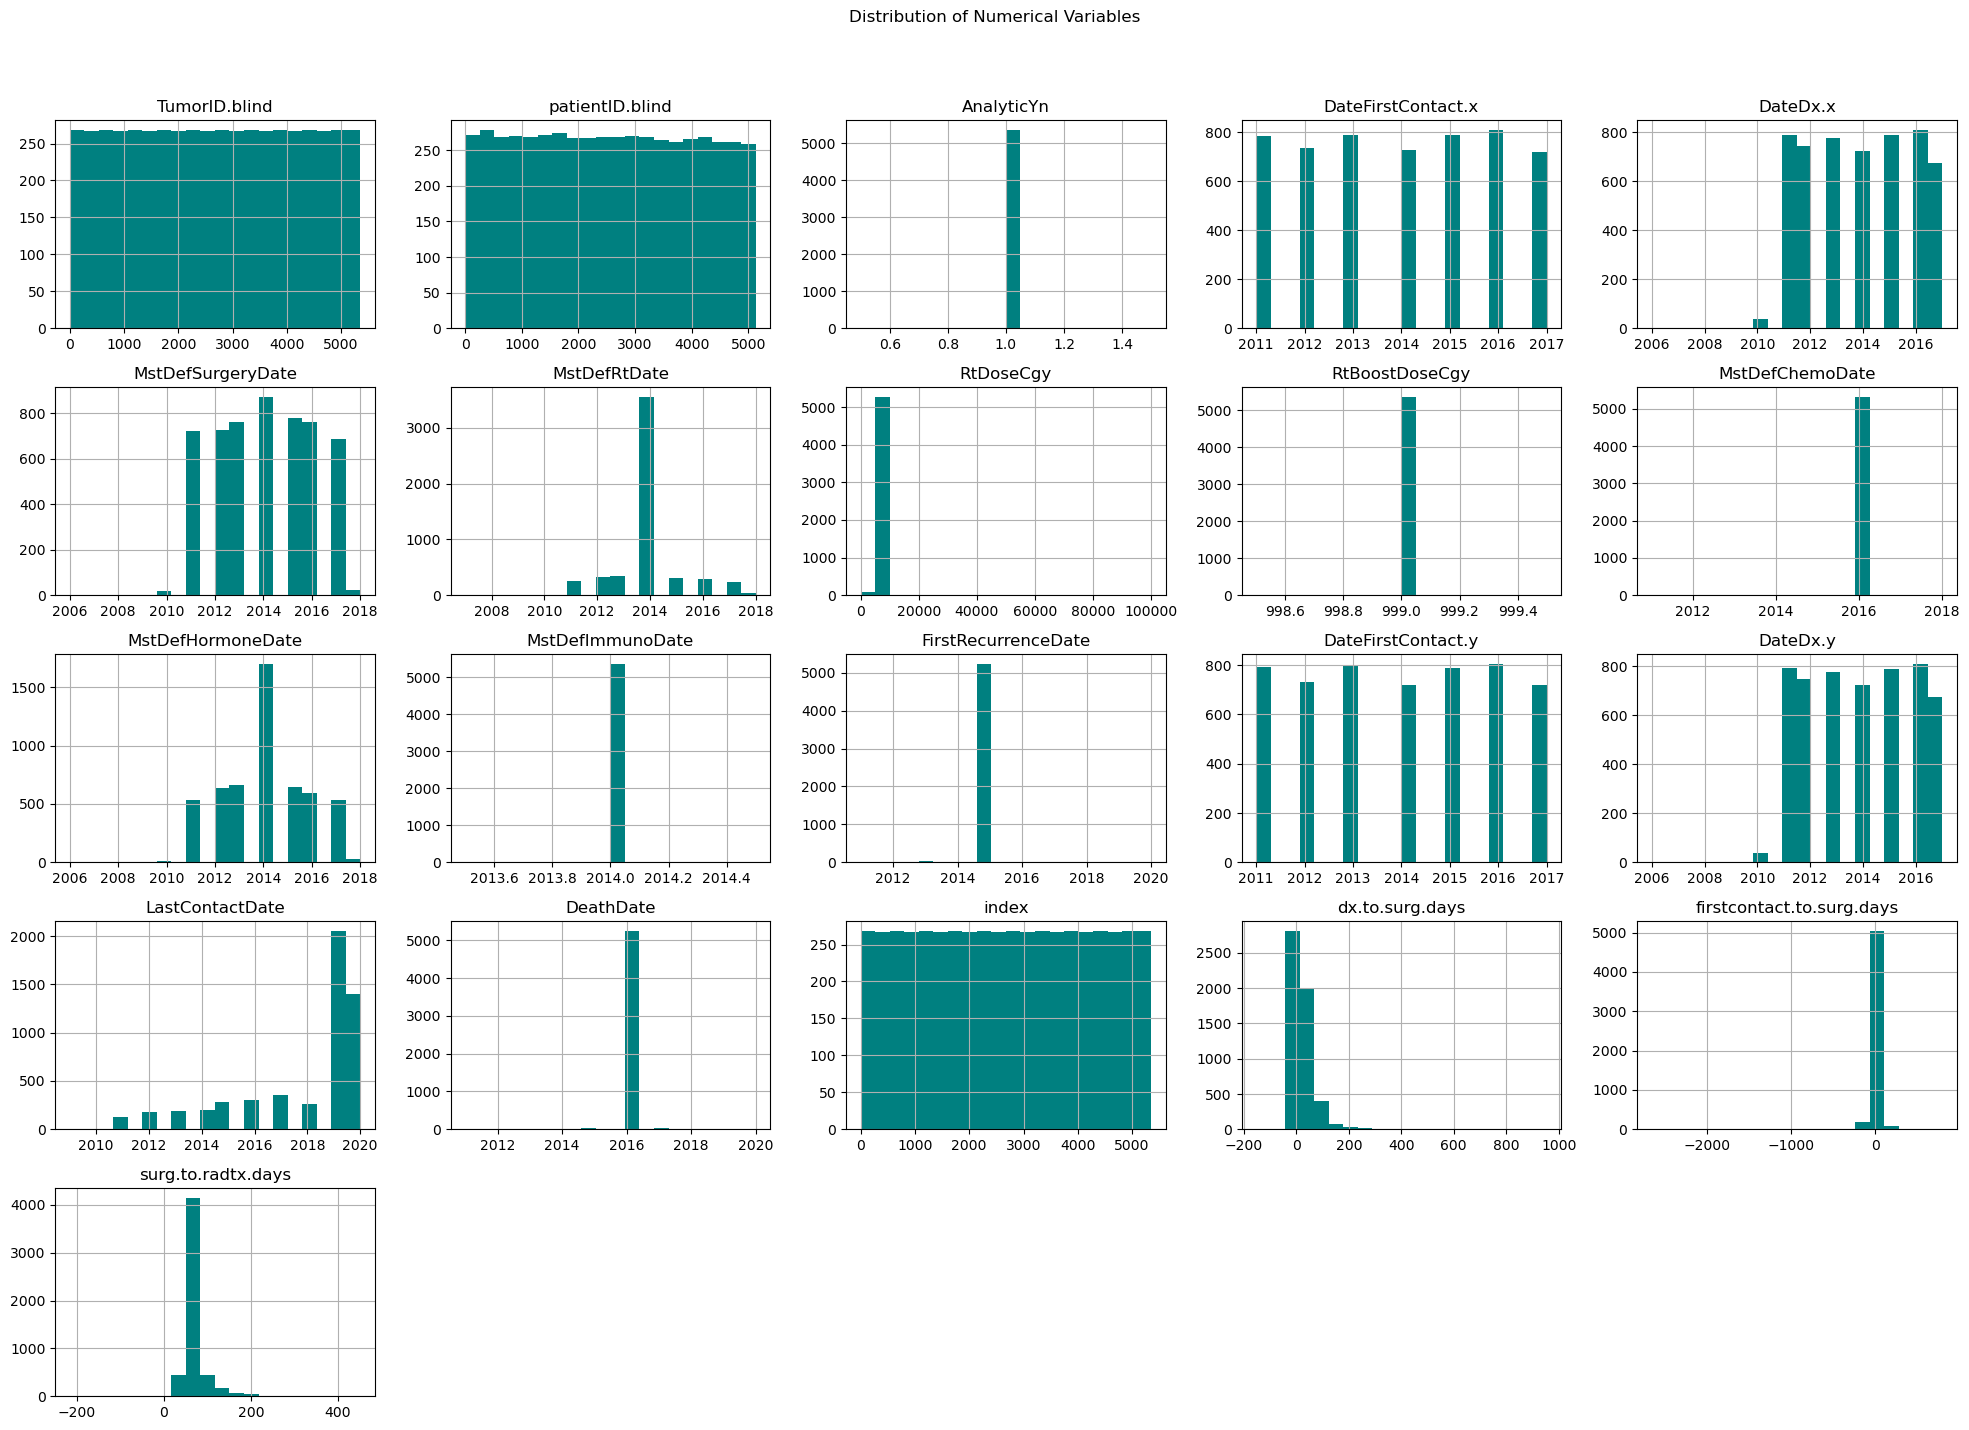

In [9]:
df.hist(bins=20, figsize=(20, 15), color='teal') # Increased height for more rows
plt.suptitle("Distribution of Numerical Variables")
plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # 'rect' prevents title overlap
plt.show()

## **Correlational HeatMap**

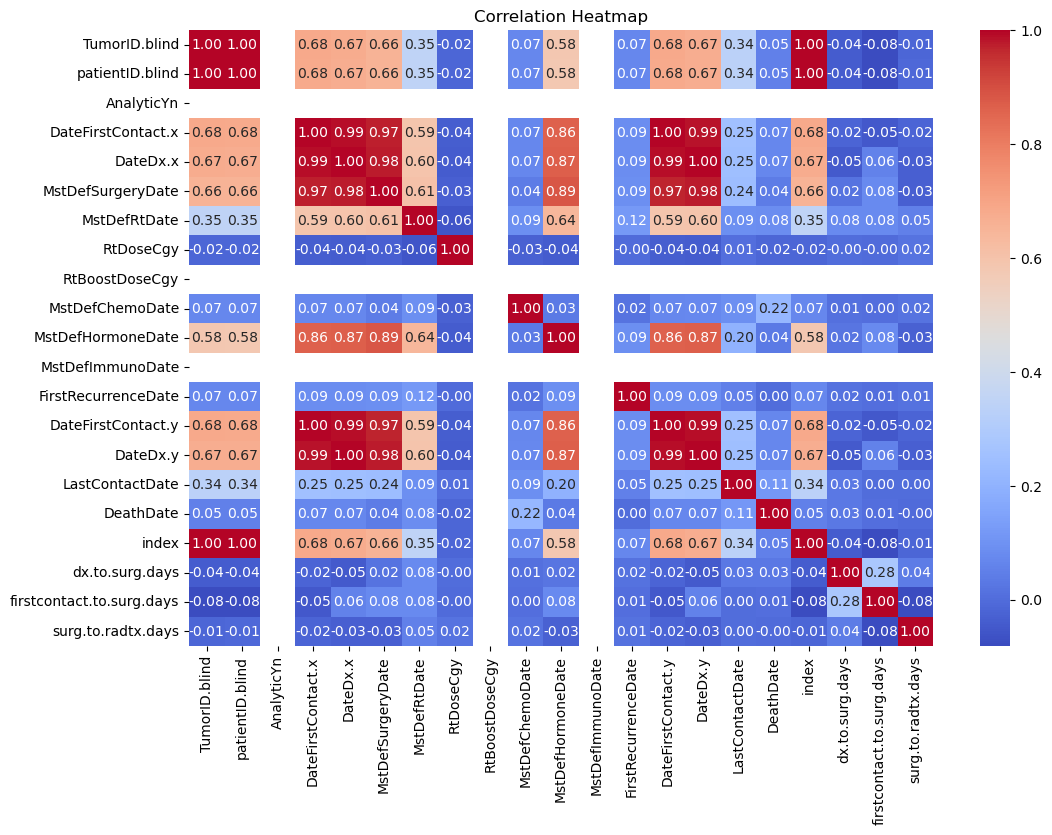

In [10]:

#  Correlation Heatmap (only for numerical features)
plt.figure(figsize=(12, 8))
numerical_df = df.select_dtypes(include=[np.number])
sns.heatmap(numerical_df.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title("Correlation Heatmap")
plt.show()

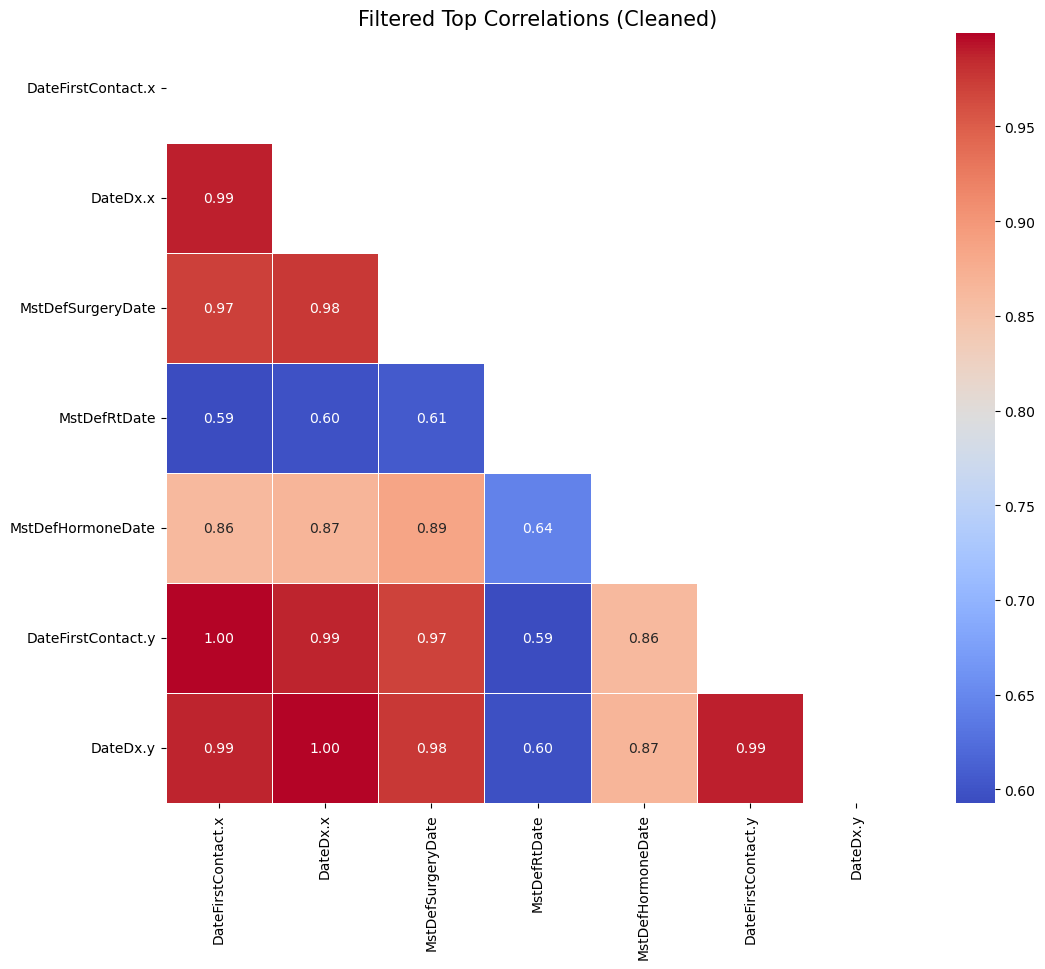

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Drop IDs and indices (highly correlated but not useful for analysis)
cols_to_ignore = ['TumorID.blind', 'patientID.blind', 'index']
numerical_df = df.select_dtypes(include=[np.number]).drop(columns=cols_to_ignore, errors='ignore')

# 2. Remove columns with zero variance or all NaNs (the 'white' rows in your image)
numerical_df = numerical_df.loc[:, numerical_df.var() > 0].dropna(axis=1, how='all')

# 3. Calculate Correlation
corr_matrix = numerical_df.corr()

# 4. Filter for Top Features (e.g., correlations stronger than 0.5)
# We look for features that have at least one strong relationship with another
threshold = 0.5
top_features = corr_matrix.index[(corr_matrix.abs() > threshold).sum() > 1]
filtered_corr = numerical_df[top_features].corr()

# 5. Plot Cleaned Heatmap
plt.figure(figsize=(12, 10))
mask = np.triu(np.ones_like(filtered_corr, dtype=bool))

sns.heatmap(filtered_corr,
            mask=mask,
            annot=True,
            cmap='coolwarm',
            fmt='.2f',
            linewidths=0.5)

plt.title("Filtered Top Correlations (Cleaned)", fontsize=15)
plt.show()

In [12]:
# 1. Remove Constant Columns (Zero Variance)
constant_cols = [col for col in df.columns if df[col].nunique() <= 1]
df_cleaned = df.drop(columns=constant_cols)

# 2. Clean 'Age' and drop non-predictive IDs
df_cleaned['AgeAtDx.x'] = pd.to_numeric(df_cleaned['AgeAtDx.x'], errors='coerce')
df_cleaned = df_cleaned.drop(columns=['TumorID.blind', 'patientID.blind', 'index'], errors='ignore')

# 3. Clean String Whitespace
for col in df_cleaned.select_dtypes(include=['object']):
    df_cleaned[col] = df_cleaned[col].apply(lambda x: x.strip() if isinstance(x, str) else x)

# 4. Handle Redundant Date/Age Versions (as seen in correlation heatmap)
redundant = ['DateFirstContact.y', 'DateDx.y', 'AgeAtDx.y']
df_cleaned = df_cleaned.drop(columns=[c for c in redundant if c in df_cleaned.columns])

# 5. Impute Missing Values
# Fill numeric with median, categorical with 'Unknown'
for col in df_cleaned.columns:
    if df_cleaned[col].dtype in ['float64', 'int64']:
        df_cleaned[col] = df_cleaned[col].fillna(df_cleaned[col].median())
    else:
        df_cleaned[col] = df_cleaned[col].fillna('Unknown')

print(f"Preprocessing complete. Cleaned shape: {df_cleaned.shape}")

Preprocessing complete. Cleaned shape: (5351, 45)


In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5351 entries, 0 to 5350
Data columns (total 59 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   TumorID.blind              5351 non-null   int64  
 1   patientID.blind            5351 non-null   int64  
 2   ReportingHospitalID        5351 non-null   object 
 3   PrimarySequence            5351 non-null   object 
 4   ClassCaseDesc              5351 non-null   object 
 5   AnalyticYn                 5351 non-null   int64  
 6   DateFirstContact.x         5351 non-null   int64  
 7   DateDx.x                   5351 non-null   int64  
 8   AgeAtDx.x                  5351 non-null   object 
 9   PrimarySiteCode            5351 non-null   object 
 10  PrimarySiteDesc            5351 non-null   object 
 11  PrimarySiteCategory        5351 non-null   object 
 12  PrimarySiteSubcategory.x   5351 non-null   object 
 13  HistologyCode              5351 non-null   objec

# **EDA**

## **Distribution of Recurrence**
This graph visualizes the class imbalance you will address in Research Question 2.

Clinical Note: Detecting the "Recurrence" group (the minority class) is the primary goal of your ML models.

C:\Users\vivek\AppData\Local\Temp\ipykernel_10132\78485441.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='recurred', data=df_cleaned, palette='viridis')


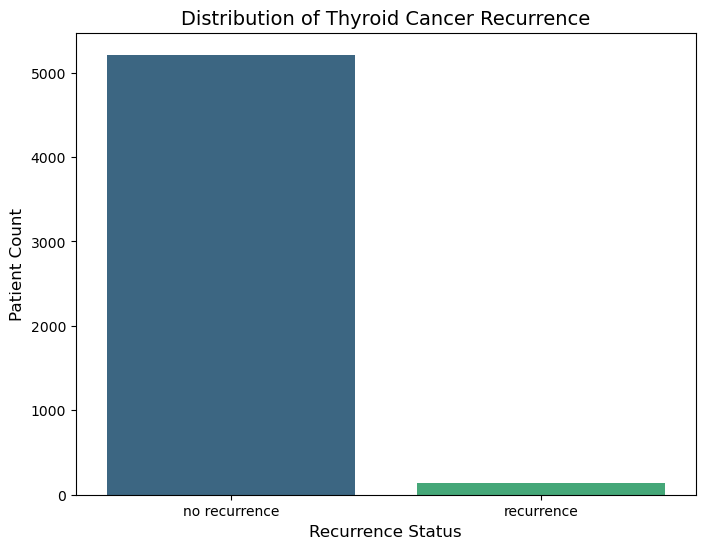

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 6))
sns.countplot(x='recurred', data=df_cleaned, palette='viridis')
plt.title('Distribution of Thyroid Cancer Recurrence', fontsize=14)
plt.xlabel('Recurrence Status', fontsize=12)
plt.ylabel('Patient Count', fontsize=12)
plt.show()

C:\Users\vivek\AppData\Local\Temp\ipykernel_10132\3158544991.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='recurred', y='AgeAtDx.x', data=df_cleaned, palette='Set2')


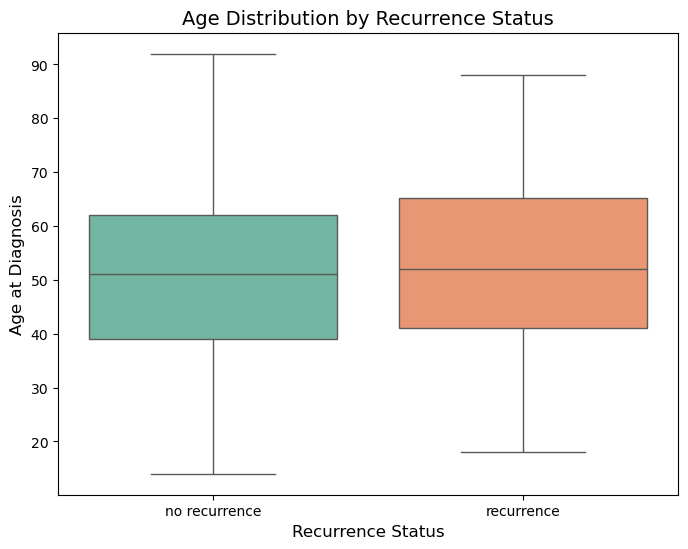

In [15]:
plt.figure(figsize=(8, 6))
sns.boxplot(x='recurred', y='AgeAtDx.x', data=df_cleaned, palette='Set2')
plt.title('Age Distribution by Recurrence Status', fontsize=14)
plt.xlabel('Recurrence Status', fontsize=12)
plt.ylabel('Age at Diagnosis', fontsize=12)
plt.show()

## **Pathology Stage vs. Recurrence**
Pathology Stage is one of the most critical features in cancer prognosis.

Clinical Note: Patients in Stage III or IV typically show a much higher frequency of recurrence events compared to Stage I.

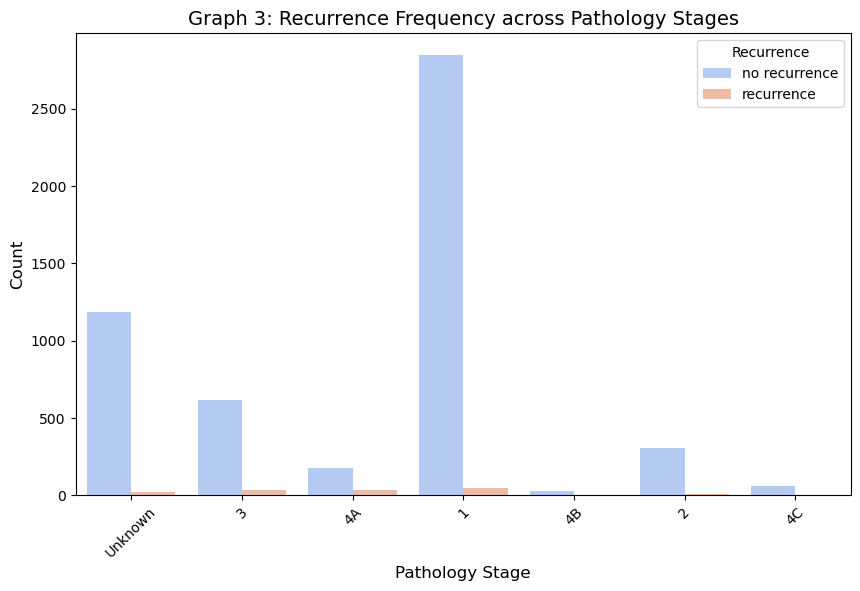

In [16]:
plt.figure(figsize=(10, 6))
# Ordering stages logically if possible, otherwise standard countplot
sns.countplot(x='PathStage', hue='recurred', data=df_cleaned, palette='coolwarm')
plt.xticks(rotation=45)
plt.title('Graph 3: Recurrence Frequency across Pathology Stages', fontsize=14)
plt.xlabel('Pathology Stage', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.legend(title='Recurrence', loc='upper right')
plt.show()

## **Gender and Recurrence**
While thyroid cancer is more common in females, some studies suggest different recurrence patterns in males.

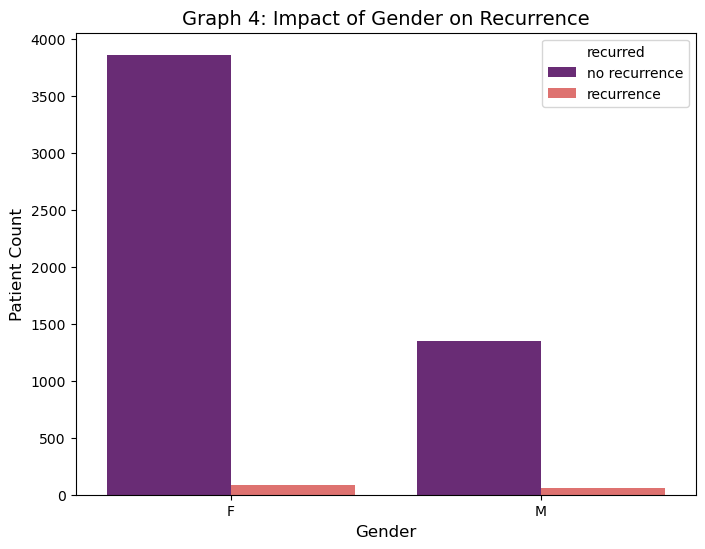

In [17]:
plt.figure(figsize=(8, 6))
sns.countplot(x='Sex', hue='recurred', data=df_cleaned, palette='magma')
plt.title('Graph 4: Impact of Gender on Recurrence', fontsize=14)
plt.xlabel('Gender', fontsize=12)
plt.ylabel('Patient Count', fontsize=12)
plt.show()

## **Feature Correlation Heatmap**
This heatmap shows how clinical variables relate to one another, helping you identify potential multi-collinearity.

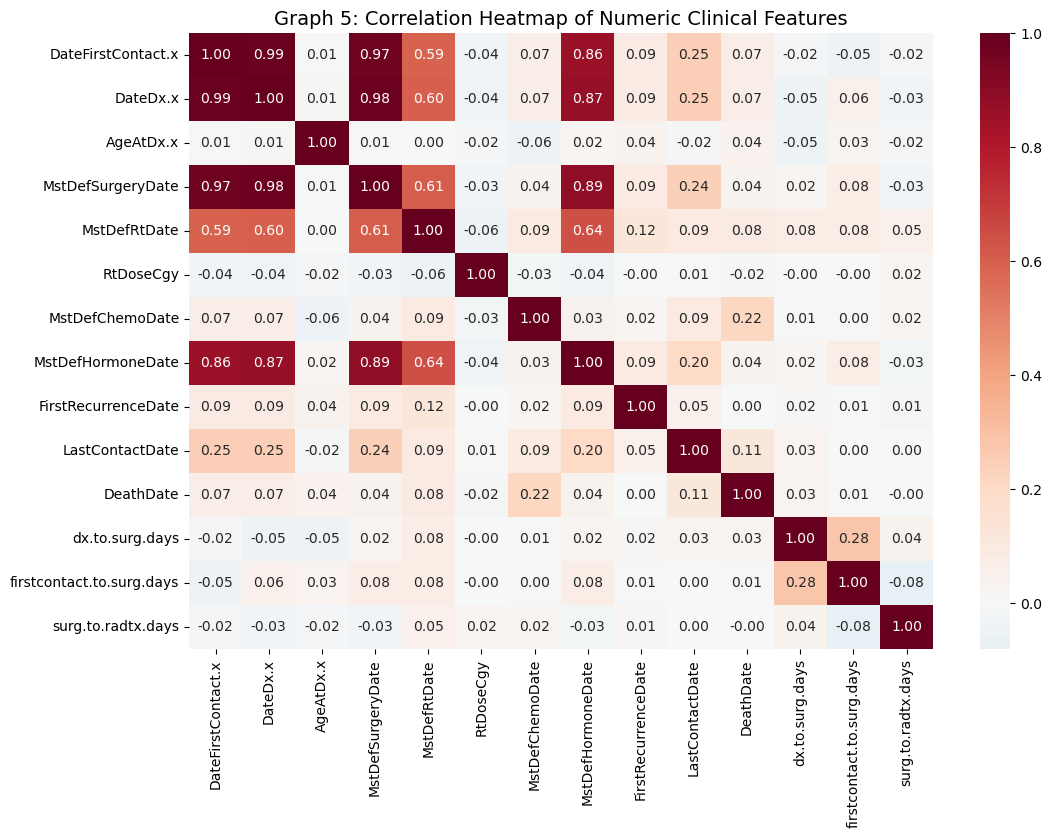

In [18]:
plt.figure(figsize=(12, 8))
numeric_df = df_cleaned.select_dtypes(include=[np.number])
correlation_matrix = numeric_df.corr()

sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap='RdBu_r', center=0)
plt.title('Graph 5: Correlation Heatmap of Numeric Clinical Features', fontsize=14)
plt.show()

# **Train-Test Split**
Now that the data is inspected and visualized, we split it to ensure we can evaluate our models on "unseen" data.

In [19]:
from sklearn.model_selection import train_test_split

# Define Features (X) and Target (y)
#  drop 'death' to avoid target leakage, as it happens after recurrence
X = df_cleaned.drop(columns=['recurred', 'death'], errors='ignore')
y = df_cleaned['recurred'].map({'no recurrence': 0, 'recurrence': 1})

# Convert categorical variables to dummy/indicator variables
X_final = pd.get_dummies(X, drop_first=True)

# 80% Training, 20% Testing
# 'stratify=y' ensures both sets have the same percentage of recurrence cases
X_train, X_test, y_train, y_test = train_test_split(
    X_final, y, test_size=0.20, random_state=42, stratify=y
)

print(f"Split complete!")
print(f"Training samples: {len(X_train)} (includes {y_train.sum()} recurrence cases)")
print(f"Testing samples: {len(X_test)} (includes {y_test.sum()} recurrence cases)")

Split complete!
Training samples: 4280 (includes 112 recurrence cases)
Testing samples: 1071 (includes 28 recurrence cases)


# **Feature Scaling & Data Preparation**

In [20]:
from sklearn.preprocessing import StandardScaler

# Initialize the Scaler
scaler = StandardScaler()

# Fit on training data and transform both sets
# We use X_train and X_test from the split we did earlier
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Variables 'X_train_scaled' and 'X_test_scaled' are now defined and ready!")

Variables 'X_train_scaled' and 'X_test_scaled' are now defined and ready!


# **Machine Learning Model**

## **MLPClassifier**

Training MLP Model...

   MLP PERFORMANCE METRICS
Accuracy:  0.9991
Precision: 1.0000
Recall:    0.9643
F1 Score:  0.9818
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1043
           1       1.00      0.96      0.98        28

    accuracy                           1.00      1071
   macro avg       1.00      0.98      0.99      1071
weighted avg       1.00      1.00      1.00      1071



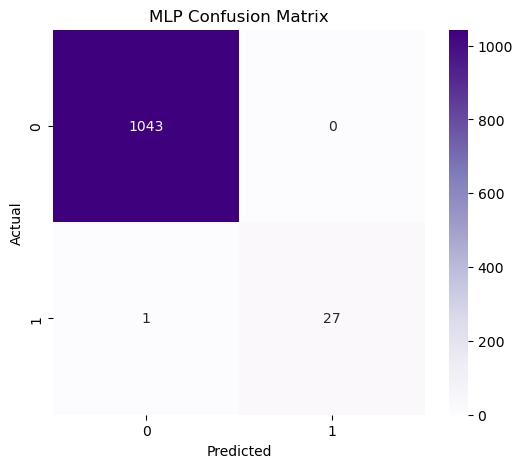

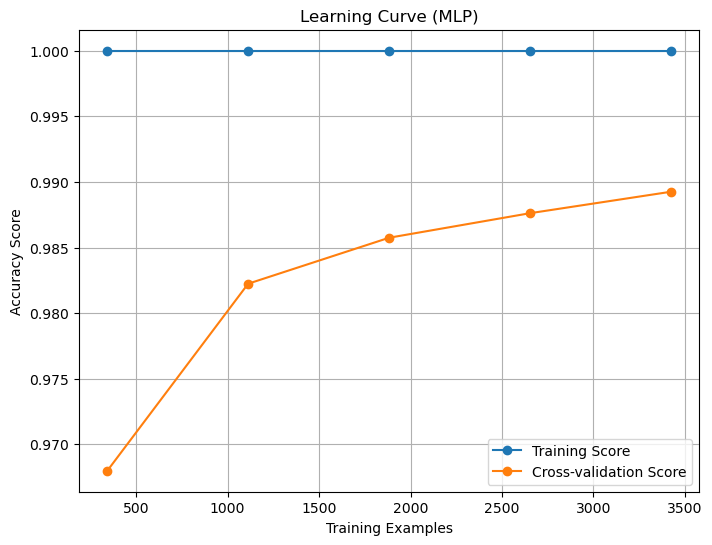

In [23]:
import time
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, precision_score, recall_score, f1_score
from sklearn.model_selection import learning_curve
import numpy as np

# 1. Initialize the MLP Model
# hidden_layer_sizes: (64, 32) means 2 hidden layers with 64 and 32 neurons
# solver: 'adam' is the optimizer (suitable for most datasets)
# activation: 'relu' is the standard non-linear function
# max_iter: number of epochs (passes through data)
mlp_model = MLPClassifier(
    hidden_layer_sizes=(64, 32),
    activation='relu',
    solver='adam',
    max_iter=500,
    random_state=42,
    verbose=False # Set to True if you want to see the loss at each iteration
)

# 2. Train the Model and measure time
print("Training MLP Model...")
start_train = time.time()
mlp_model.fit(X_train_scaled, y_train)
end_train = time.time()

# 3. Evaluate the Model with specific metrics
y_pred = mlp_model.predict(X_test_scaled)

# Calculate individual metrics
acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print(f"\n{'='*30}")
print("   MLP PERFORMANCE METRICS")
print(f"{'='*30}")
print(f"Accuracy:  {acc:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall:    {rec:.4f}")
print(f"F1 Score:  {f1:.4f}")
print(f"{'='*30}")

print(classification_report(y_test, y_pred))

# 4. Plot Confusion Matrix
plt.figure(figsize=(6, 5))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Purples')
plt.title('MLP Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# 5. Plot Learning Curve
# This shows how the model improves as it sees more data
train_sizes, train_scores, test_scores = learning_curve(
    mlp_model, X_train_scaled, y_train, cv=5, scoring='accuracy',
    train_sizes=np.linspace(0.1, 1.0, 5), n_jobs=-1
)

train_mean = np.mean(train_scores, axis=1)
test_mean = np.mean(test_scores, axis=1)

plt.figure(figsize=(8, 6))
plt.plot(train_sizes, train_mean, 'o-', label="Training Score")
plt.plot(train_sizes, test_mean, 'o-', label="Cross-validation Score")
plt.title("Learning Curve (MLP)")
plt.xlabel("Training Examples")
plt.ylabel("Accuracy Score")
plt.legend(loc="best")
plt.grid()
plt.show()

## **Random Forest Model**
Random Forest is an ensemble of decision trees. It is robust and usually requires less feature scaling than MLPs.

--- Random Forest Performance ---
Train Time: 0.3935s
Accuracy:  0.9972
Precision: 1.0000
Recall:    0.8929
F1 Score:  0.9434


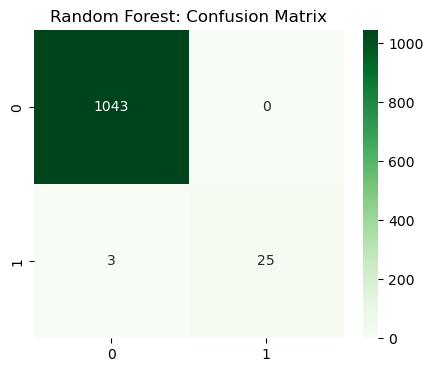

In [24]:
from sklearn.ensemble import RandomForestClassifier


# 1. Initialize Random Forest
rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=None,
    random_state=42,
    class_weight='balanced'
)

# 2. Train and Time
start_train = time.time()
rf_model.fit(X_train_scaled, y_train)
train_time = time.time() - start_train

# 3. Predict and Evaluate
y_pred_rf = rf_model.predict(X_test_scaled)

print(f"--- Random Forest Performance ---")
print(f"Train Time: {train_time:.4f}s")
print(f"Accuracy:  {accuracy_score(y_test, y_pred_rf):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_rf):.4f}")
print(f"Recall:    {recall_score(y_test, y_pred_rf):.4f}")
print(f"F1 Score:  {f1_score(y_test, y_pred_rf):.4f}")

# 4. Confusion Matrix
plt.figure(figsize=(5,4))
sns.heatmap(confusion_matrix(y_test, y_pred_rf), annot=True, fmt='d', cmap='Greens')
plt.title("Random Forest: Confusion Matrix")
plt.show()

## **XGBoost Model**
XGBoost uses Gradient Boosting. It builds trees sequentially, where each new tree tries to correct the errors made by the previous ones.

In [27]:
!pip install xgboost


   ---------------------------------------- 0.0/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.0/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.5/101.7 MB 3.1 MB/s eta 0:00:33
   ---------------------------------------- 0.8/101.7 MB 2.2 MB/s eta 0:00:47
    --------------------------------------- 1.3/101.7 MB 2.3 MB/s eta 0:00:43
    --------------------------------------- 1.6/101.7 MB 2.0 MB/s eta 0:00:51
    --------------------------------------- 2.4/101.7 MB 2.3 MB/s eta 0:00:43
   - -------------------------------------- 2.6/101.7 MB 2.2 MB/s eta 0:00:45
   - -------------------------------------- 3.1/101.7 MB 2.1 MB/s eta 0:00:46
   - -------------------------------------- 3.9/101.7 MB 2.4 MB/s eta 0:00:41
   - -------------------------------------- 5.0/101.7 MB 2.7 MB/s eta 0:00:37
   -- ------------------------------------- 6.0/101.7 MB 2.9 MB/s eta 0:00:34
   -- ------------------------------------- 7.3/101.7 MB 3.2 MB/s eta 0:00:30


C:\Users\vivek\anaconda3\Lib\site-packages\xgboost\training.py:200: UserWarning: [20:15:41] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


--- XGBoost Performance ---
Train Time: 0.1981s
Accuracy:  0.9991
Precision: 1.0000
Recall:    0.9643
F1 Score:  0.9818


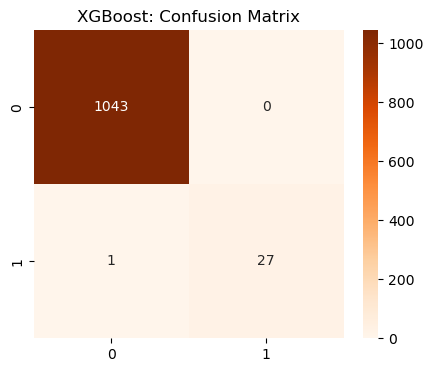

In [28]:
from xgboost import XGBClassifier

# 1. Initialize XGBoost
# Note: eval_metric='logloss' addresses your professor's point about checking loss functions.
xgb_model = XGBClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=6,
    eval_metric='logloss',
    use_label_encoder=False,
    random_state=42
)

# 2. Train and Time
start_train = time.time()
xgb_model.fit(X_train_scaled, y_train)
train_time = time.time() - start_train

# 3. Predict and Evaluate
y_pred_xgb = xgb_model.predict(X_test_scaled)

print(f"--- XGBoost Performance ---")
print(f"Train Time: {train_time:.4f}s")
print(f"Accuracy:  {accuracy_score(y_test, y_pred_xgb):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_xgb):.4f}")
print(f"Recall:    {recall_score(y_test, y_pred_xgb):.4f}")
print(f"F1 Score:  {f1_score(y_test, y_pred_xgb):.4f}")

# 4. Confusion Matrix
plt.figure(figsize=(5,4))
sns.heatmap(confusion_matrix(y_test, y_pred_xgb), annot=True, fmt='d', cmap='Oranges')
plt.title("XGBoost: Confusion Matrix")
plt.show()

 # **Hyperparameter Tuning & Evaluation**


## **MLP**

Starting Grid Search for MLP... (This may take a moment)
Fitting 3 folds for each of 48 candidates, totalling 144 fits

Best Parameters Found: {'activation': 'relu', 'alpha': 0.05, 'hidden_layer_sizes': (100,), 'learning_rate': 'constant', 'solver': 'adam'}

   OPTIMIZED MLP PERFORMANCE
Accuracy:  1.0000
Precision: 1.0000
Recall:    1.0000
F1 Score:  1.0000


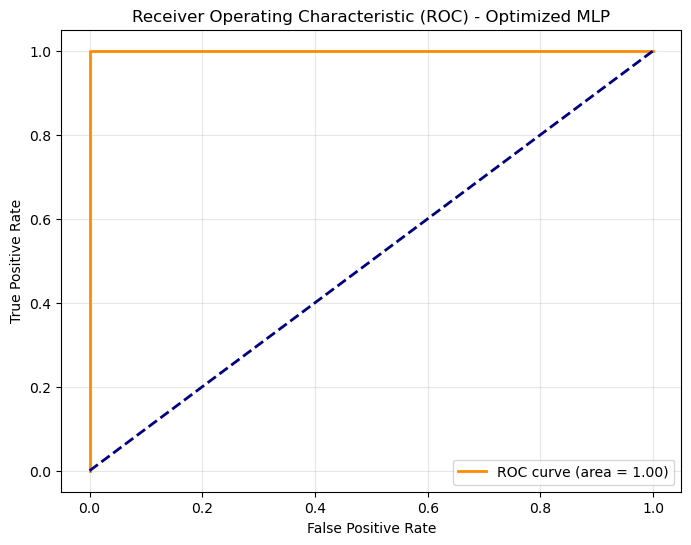

In [31]:
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score, roc_curve, auc, RocCurveDisplay
import matplotlib.pyplot as plt
import time

# 1. Define the Parameter Grid
# We test different architectures and optimizers (solvers)
param_grid = {
    'hidden_layer_sizes': [(50,), (100,), (50, 25)], # 1 layer vs 2 layers
    'activation': ['relu', 'tanh'],                # Different non-linear functions
    'solver': ['adam', 'sgd'],                     # The Optimizers
    'alpha': [0.0001, 0.05],                       # L2 penalty (Regularization)
    'learning_rate': ['constant','adaptive'],
}

# 2. Initialize Grid Search
# cv=5 means 5-fold cross-validation
mlp_search = GridSearchCV(MLPClassifier(max_iter=500, random_state=42),
                          param_grid, n_jobs=-1, cv=3, verbose=1)

print("Starting Grid Search for MLP... (This may take a moment)")
mlp_search.fit(X_train_scaled, y_train)

# 3. Get the Best Model
best_mlp = mlp_search.best_estimator_
print(f"\nBest Parameters Found: {mlp_search.best_params_}")

# 4. Evaluate on Test Set
y_pred = best_mlp.predict(X_test_scaled)
y_probs = best_mlp.predict_proba(X_test_scaled)[:, 1] # Needed for ROC Curve

# 5. Print All Metrics
print(f"\n{'='*35}")
print("   OPTIMIZED MLP PERFORMANCE")
print(f"{'='*35}")
print(f"Accuracy:  {accuracy_score(y_test, y_pred):.4f}")
print(f"Precision: {precision_score(y_test, y_pred):.4f}")
print(f"Recall:    {recall_score(y_test, y_pred):.4f}")
print(f"F1 Score:  {f1_score(y_test, y_pred):.4f}")
print(f"{'='*35}")

# 6. Plot ROC Curve
# The ROC curve shows the trade-off between sensitivity and specificity
fpr, tpr, _ = roc_curve(y_test, y_probs)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) - Optimized MLP')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()

## Grid Search for Random Forest and XGBoost

In [32]:
import pandas as pd
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

# Define parameter grids for both models
rf_params = {
    'n_estimators': [100, 200],
    'max_depth': [10, 20, None],
    'min_samples_split': [2, 5],
    'class_weight': ['balanced']
}

xgb_params = {
    'n_estimators': [100, 200],
    'learning_rate': [0.01, 0.1],
    'max_depth': [3, 6],
    'eval_metric': ['logloss']
}

# --- 1. Random Forest Grid Search ---
print("Tuning Random Forest...")
rf_grid = GridSearchCV(RandomForestClassifier(random_state=42), rf_params, cv=3, scoring='f1', n_jobs=-1)
rf_grid.fit(X_train_scaled, y_train)
best_rf = rf_grid.best_estimator_

# --- 2. XGBoost Grid Search ---
print("Tuning XGBoost...")
xgb_grid = GridSearchCV(XGBClassifier(random_state=42, use_label_encoder=False), xgb_params, cv=3, scoring='f1', n_jobs=-1)
xgb_grid.fit(X_train_scaled, y_train)
best_xgb = xgb_grid.best_estimator_

Tuning Random Forest...
Tuning XGBoost...


C:\Users\vivek\anaconda3\Lib\site-packages\xgboost\training.py:200: UserWarning: [20:21:32] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


## **Performance Comparison Table**

In [33]:
def get_metrics(model, name, X_test, y_test):
    preds = model.predict(X_test)
    probs = model.predict_proba(X_test)[:, 1]
    return {
        "Model": name,
        "Accuracy": accuracy_score(y_test, preds),
        "Precision": precision_score(y_test, preds),
        "Recall": recall_score(y_test, preds),
        "F1 Score": f1_score(y_test, preds),
        "ROC-AUC": roc_auc_score(y_test, probs),
        "Best Parameters": str(model.get_params() if hasattr(model, 'get_params') else "N/A")
    }

# Assuming 'best_mlp' was defined in the previous step
all_results = [
    get_metrics(best_mlp, "MLP (Optimized)", X_test_scaled, y_test),
    get_metrics(best_rf, "Random Forest (Optimized)", X_test_scaled, y_test),
    get_metrics(best_xgb, "XGBoost (Optimized)", X_test_scaled, y_test)
]

comparison_df = pd.DataFrame(all_results)

# Display the table
print("\n--- FINAL MODEL COMPARISON ---")
display(comparison_df[['Model', 'Accuracy', 'Precision', 'Recall', 'F1 Score', 'ROC-AUC']])

# Print best parameters separately for readability
for res in all_results:
    print(f"\nBest params for {res['Model']}:\n{res['Best Parameters']}")


--- FINAL MODEL COMPARISON ---


,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,MLP (Optimized),1.000000,1.000000,1.000000,1.000000,1.000000
1,Random Forest (Optimized),0.997199,0.962963,0.928571,0.945455,0.999178
2,XGBoost (Optimized),1.000000,1.000000,1.000000,1.000000,1.000000



Best params for MLP (Optimized):
{'activation': 'relu', 'alpha': 0.05, 'batch_size': 'auto', 'beta_1': 0.9, 'beta_2': 0.999, 'early_stopping': False, 'epsilon': 1e-08, 'hidden_layer_sizes': (100,), 'learning_rate': 'constant', 'learning_rate_init': 0.001, 'max_fun': 15000, 'max_iter': 500, 'momentum': 0.9, 'n_iter_no_change': 10, 'nesterovs_momentum': True, 'power_t': 0.5, 'random_state': 42, 'shuffle': True, 'solver': 'adam', 'tol': 0.0001, 'validation_fraction': 0.1, 'verbose': False, 'warm_start': False}

Best params for Random Forest (Optimized):
{'bootstrap': True, 'ccp_alpha': 0.0, 'class_weight': 'balanced', 'criterion': 'gini', 'max_depth': 10, 'max_features': 'sqrt', 'max_leaf_nodes': None, 'max_samples': None, 'min_impurity_decrease': 0.0, 'min_samples_leaf': 1, 'min_samples_split': 5, 'min_weight_fraction_leaf': 0.0, 'monotonic_cst': None, 'n_estimators': 200, 'n_jobs': None, 'oob_score': False, 'random_state': 42, 'verbose': 0, 'warm_start': False}

Best params for XGBoost

## **Plotting Confusion Matrices for All Models**

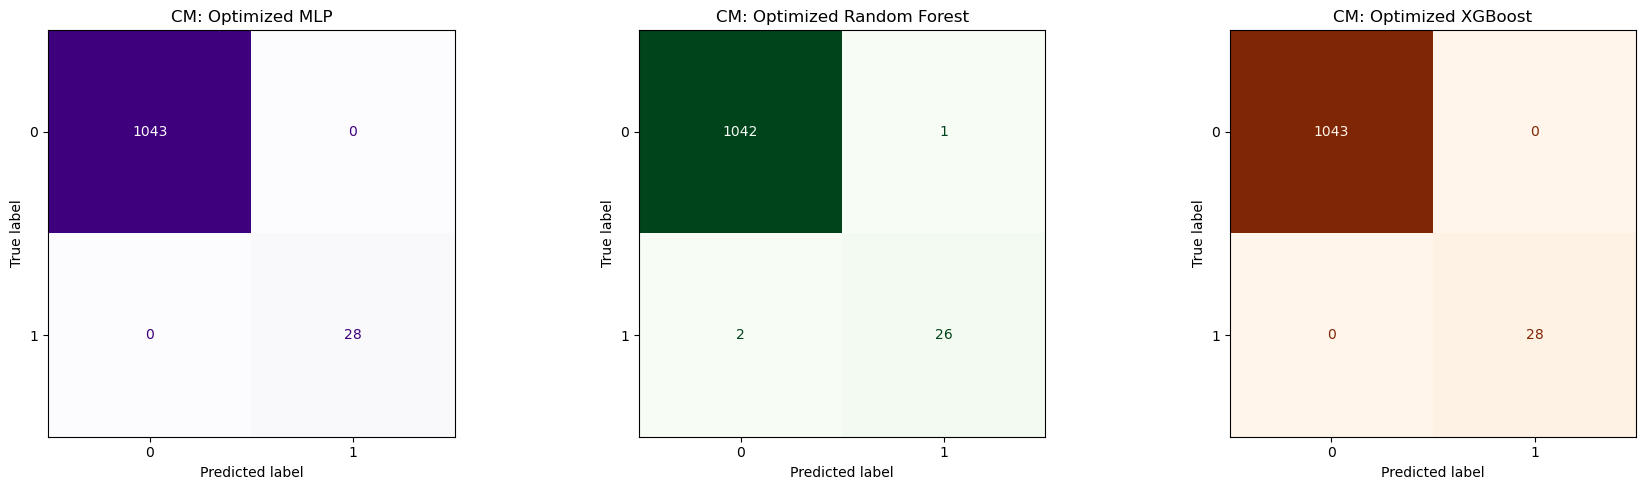

In [34]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Create a figure with 3 subplots
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# List of optimized models and their names
best_models = [
    (best_mlp, "Optimized MLP", "Purples"),
    (best_rf, "Optimized Random Forest", "Greens"),
    (best_xgb, "Optimized XGBoost", "Oranges")
]

for i, (model, name, color) in enumerate(best_models):
    y_pred = model.predict(X_test_scaled)
    cm = confusion_matrix(y_test, y_pred)

    # Using ConfusionMatrixDisplay for a professional look
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot(ax=axes[i], cmap=color, colorbar=False)
    axes[i].set_title(f"CM: {name}")

plt.tight_layout()
plt.show()

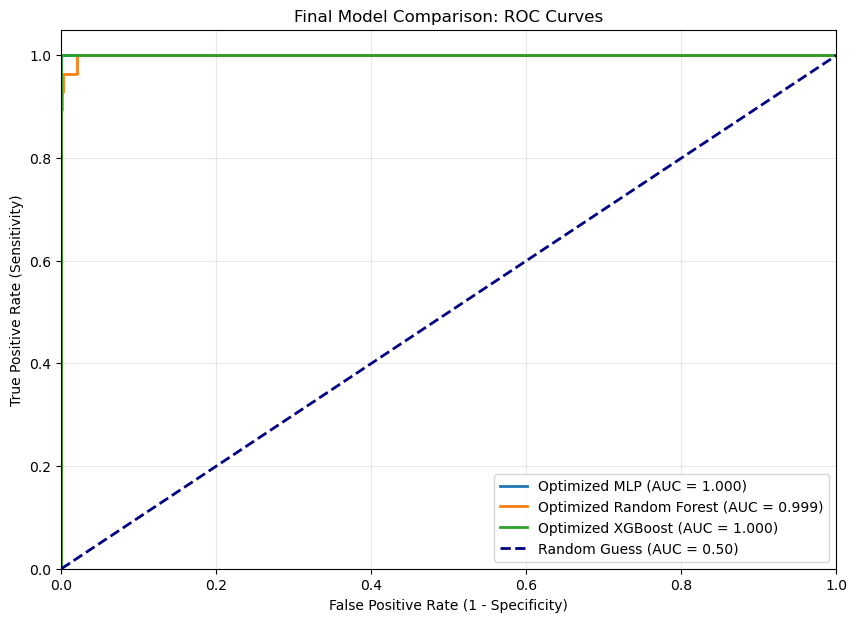

In [35]:
from sklearn.metrics import roc_curve, auc

plt.figure(figsize=(10, 7))

for model, name, color in best_models:
    # Get probabilities for the positive class
    y_probs = model.predict_proba(X_test_scaled)[:, 1]

    # Calculate FPR and TPR
    fpr, tpr, _ = roc_curve(y_test, y_probs)
    roc_auc = auc(fpr, tpr)

    # Plot each curve
    plt.plot(fpr, tpr, lw=2, label=f'{name} (AUC = {roc_auc:.3f})')

# Plot the "Random Guess" diagonal line
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Guess (AUC = 0.50)')

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (1 - Specificity)')
plt.ylabel('True Positive Rate (Sensitivity)')
plt.title('Final Model Comparison: ROC Curves')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()

# **Cross-Validation**

In [36]:
import numpy as np
from sklearn.model_selection import cross_validate

# 1. Define the metrics to track
scoring_metrics = ['accuracy', 'precision', 'recall', 'f1', 'roc_auc']

def perform_detailed_cv(model, name, X, y):
    print(f"\n{'='*45}")
    print(f" 5-Fold Cross-Validation: {name}")
    print(f"{'='*45}")

    # Run the cross-validation
    cv_results = cross_validate(
        model, X, y, cv=5,
        scoring=scoring_metrics,
        n_jobs=-1
    )

    # Print Header
    print(f"{'Metric':<15} | {'Mean Score':<12} | {'Std Deviation':<12}")
    print("-" * 45)

    # Calculate and display Mean and Std Dev for each metric
    for metric in scoring_metrics:
        scores = cv_results[f'test_{metric}']
        mean_val = scores.mean()
        std_val = scores.std()

        print(f"{metric.upper():<15} | {mean_val:.4f}      | {std_val:.4f}")

# 2. Execute for all three optimized models
# Assuming best_mlp, best_rf, and best_xgb are your tuned estimators
perform_detailed_cv(best_mlp, "MLP (Optimized)", X_train_scaled, y_train)
perform_detailed_cv(best_rf, "Random Forest (Optimized)", X_train_scaled, y_train)
perform_detailed_cv(best_xgb, "XGBoost (Optimized)", X_train_scaled, y_train)


 5-Fold Cross-Validation: MLP (Optimized)
Metric          | Mean Score   | Std Deviation
---------------------------------------------
ACCURACY        | 0.9977      | 0.0007
PRECISION       | 0.9833      | 0.0333
RECALL          | 0.9285      | 0.0222
F1              | 0.9544      | 0.0130
ROC_AUC         | 0.9992      | 0.0011

 5-Fold Cross-Validation: Random Forest (Optimized)
Metric          | Mean Score   | Std Deviation
---------------------------------------------
ACCURACY        | 0.9944      | 0.0028
PRECISION       | 1.0000      | 0.0000
RECALL          | 0.7854      | 0.1089
F1              | 0.8757      | 0.0667
ROC_AUC         | 0.9993      | 0.0007

 5-Fold Cross-Validation: XGBoost (Optimized)
Metric          | Mean Score   | Std Deviation
---------------------------------------------
ACCURACY        | 0.9998      | 0.0005
PRECISION       | 0.9917      | 0.0167
RECALL          | 1.0000      | 0.0000
F1              | 0.9957      | 0.0085
ROC_AUC         | 1.0000      | 

# **Explianable AI interpretition**

## **Implementing SHAP for MLP**
I will use KernelExplainer, which is the most versatile way to explain any model's output.

In [40]:
!pip install shap

   ---------------------------------------- 0.0/555.9 kB ? eta -:--:--
   ---------------------------------------- 0.0/555.9 kB ? eta -:--:--
   ------------------ --------------------- 262.1/555.9 kB ? eta -:--:--
   ---------------------------------------- 555.9/555.9 kB 1.8 MB/s  0:00:00

   -------------------- ------------------- 1/2 [shap]
   -------------------- ------------------- 1/2 [shap]
   -------------------- ------------------- 1/2 [shap]
   -------------------- ------------------- 1/2 [shap]
   -------------------- ------------------- 1/2 [shap]
   -------------------- ------------------- 1/2 [shap]
   -------------------- ------------------- 1/2 [shap]
   -------------------- ------------------- 1/2 [shap]
   -------------------- ------------------- 1/2 [shap]
   -------------------- ------------------- 1/2 [shap]
   -------------------- ------------------- 1/2 [shap]
   ---------------------------------------- 2/2 [shap]



  0%|          | 0/50 [00:00<?, ?it/s]

C:\Users\vivek\anaconda3\Lib\site-packages\shap\plots\_beeswarm.py:1150: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()
C:\Users\vivek\AppData\Local\Temp\ipykernel_10132\3388425417.py:38: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


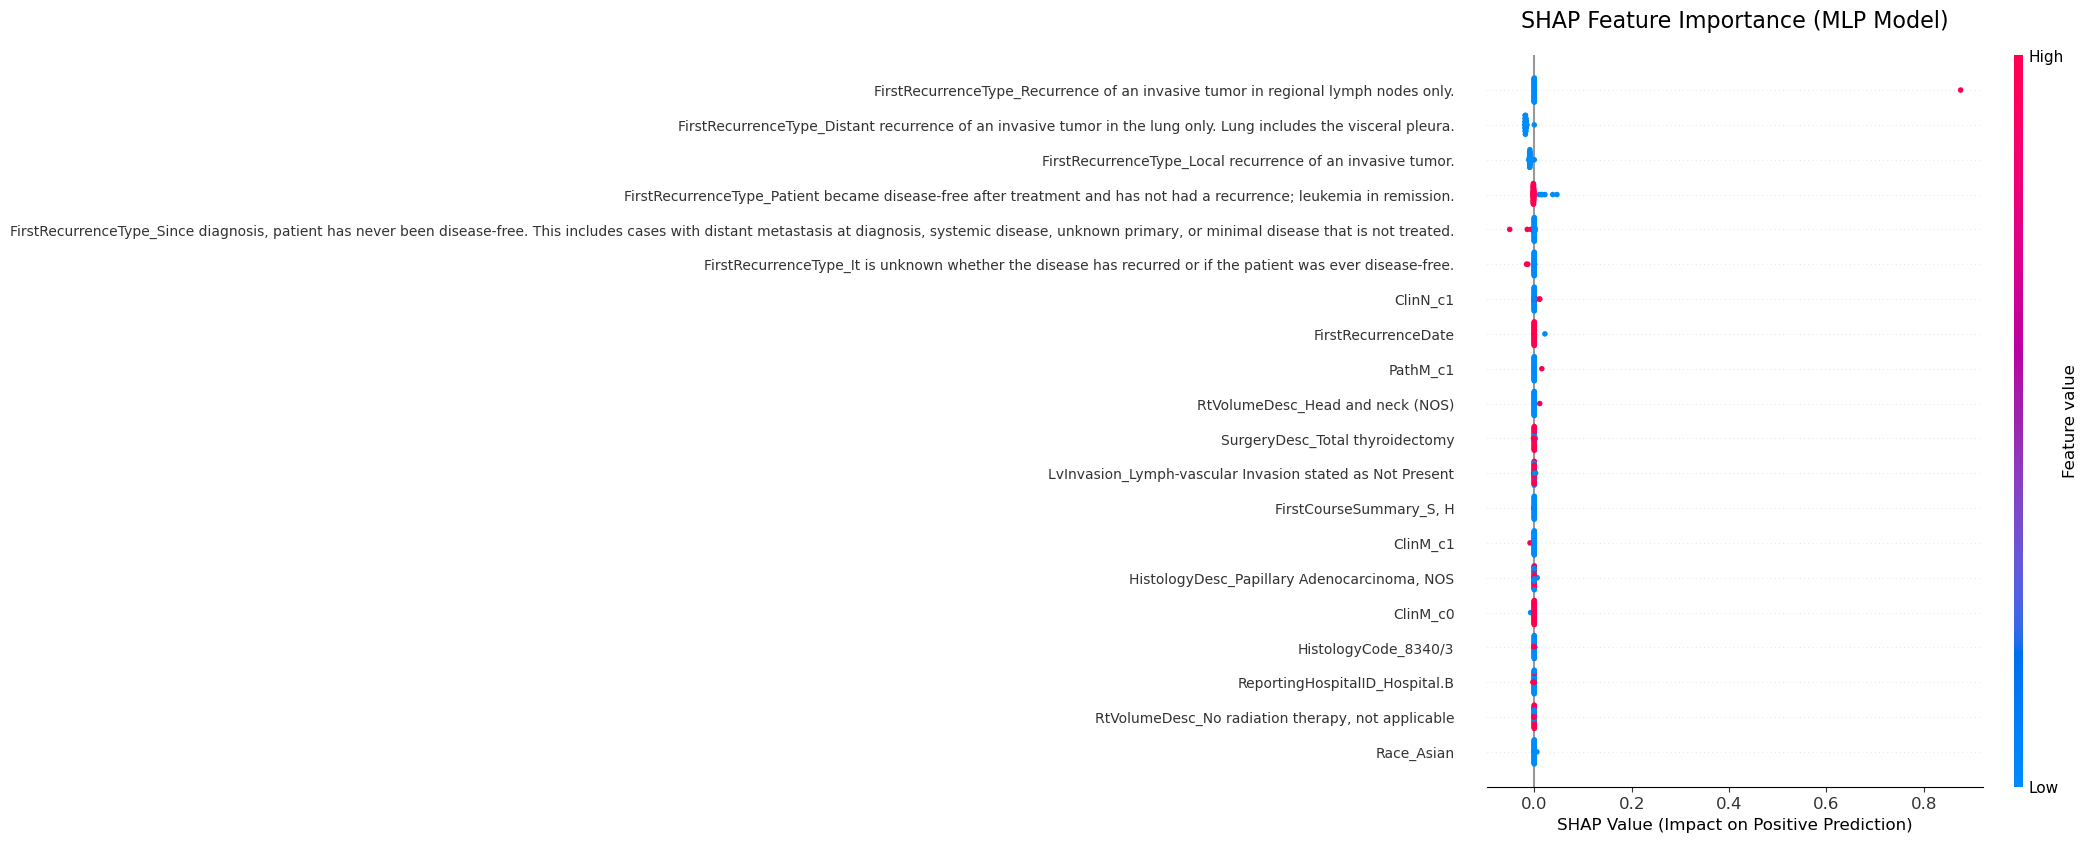

In [41]:
import shap
import matplotlib.pyplot as plt

# 1. Prepare background (100 samples is a good balance for speed/accuracy)
background = X_train_scaled[:100]

# 2. Initialize the Explainer
# Using the lambda fix to focus only on the positive class probability
explainer = shap.KernelExplainer(lambda x: best_mlp.predict_proba(x)[:, 1], background)

# 3. Calculate SHAP values (subset of test data)
test_samples = X_test_scaled[:50]
shap_values = explainer.shap_values(test_samples)

# 4. ENHANCED VISUALIZATION
# Set the plot size larger to accommodate long feature names
plt.figure(figsize=(12, 10))

# Adjusting the plot parameters:
# plot_size: explicitly controls height and width
# show=False: allows us to customize with plt before displaying
shap.summary_plot(
    shap_values,
    test_samples,
    feature_names=X_train.columns,
    max_display=20,      # Show top 20 features for clarity
    plot_type="dot",     # Ensure it's the dot plot shown in your image
    show=False           # Allow further customization
)

# Customizing plot aesthetics for visibility
plt.title("SHAP Feature Importance (MLP Model)", fontsize=16, pad=20)
plt.xlabel("SHAP Value (Impact on Positive Prediction)", fontsize=12)
plt.yticks(fontsize=10) # Makes long feature names slightly smaller to fit
plt.xticks(fontsize=12)

# This prevents the labels from being cut off on the left
plt.tight_layout()

plt.show()

  0%|          | 0/40 [00:00<?, ?it/s]

C:\Users\vivek\anaconda3\Lib\site-packages\shap\plots\_beeswarm.py:1150: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()
C:\Users\vivek\AppData\Local\Temp\ipykernel_10132\1329251577.py:27: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout() # Crucial: Adjusts margins so labels aren't cut off


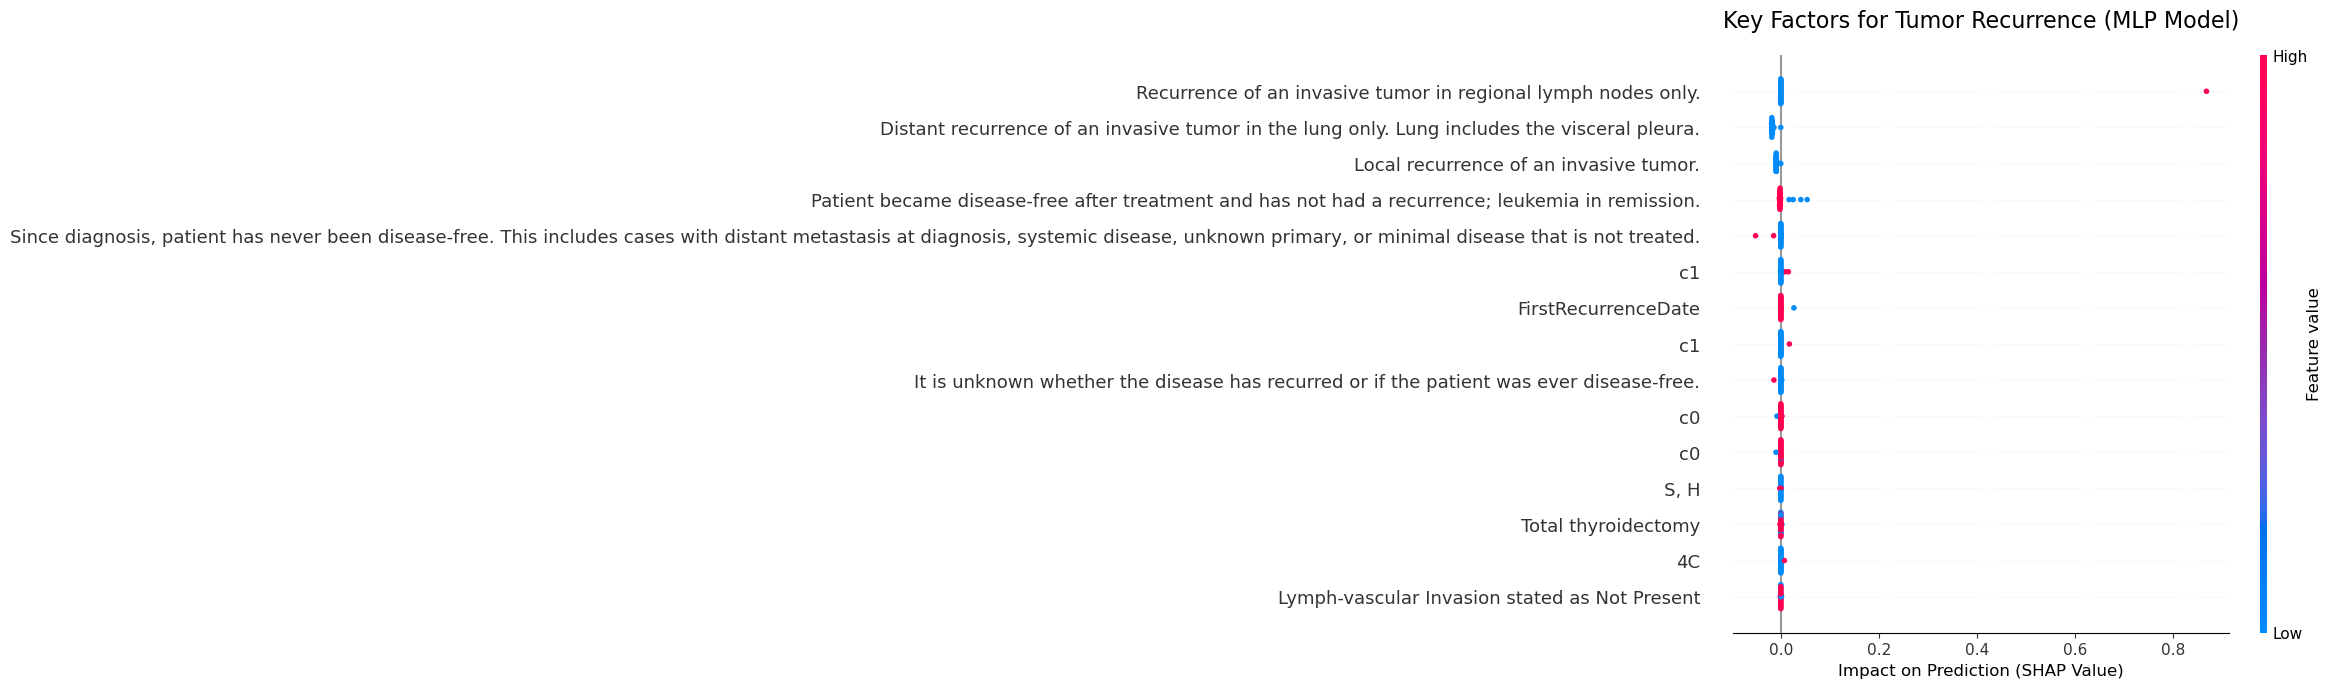

In [42]:
import shap
import matplotlib.pyplot as plt

# 1. Cleaner labels: Shortens "ColumnName_LongValueName" to just "ValueName"
# This prevents the "large sentences" issue you mentioned.
clean_feature_names = [col.split('_')[-1] if '_' in col else col for col in X_train.columns]

# 2. Re-calculate with optimized plot settings
background = X_train_scaled[:100]
explainer = shap.KernelExplainer(lambda x: best_mlp.predict_proba(x)[:, 1], background)
test_samples = X_test_scaled[:40]
shap_values = explainer.shap_values(test_samples)

# 3. Enhanced Visualization
plt.figure(figsize=(14, 8)) # Wider plot to give text room
shap.summary_plot(
    shap_values,
    test_samples,
    feature_names=clean_feature_names,
    max_display=15,    # Show only top 15 to reduce clutter
    plot_type="dot",
    show=False
)

plt.title("Key Factors for Tumor Recurrence (MLP Model)", fontsize=16, pad=20)
plt.xlabel("Impact on Prediction (SHAP Value)", fontsize=12)
plt.tight_layout() # Crucial: Adjusts margins so labels aren't cut off
plt.show()

C:\Users\vivek\anaconda3\Lib\site-packages\shap\plots\_beeswarm.py:1150: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


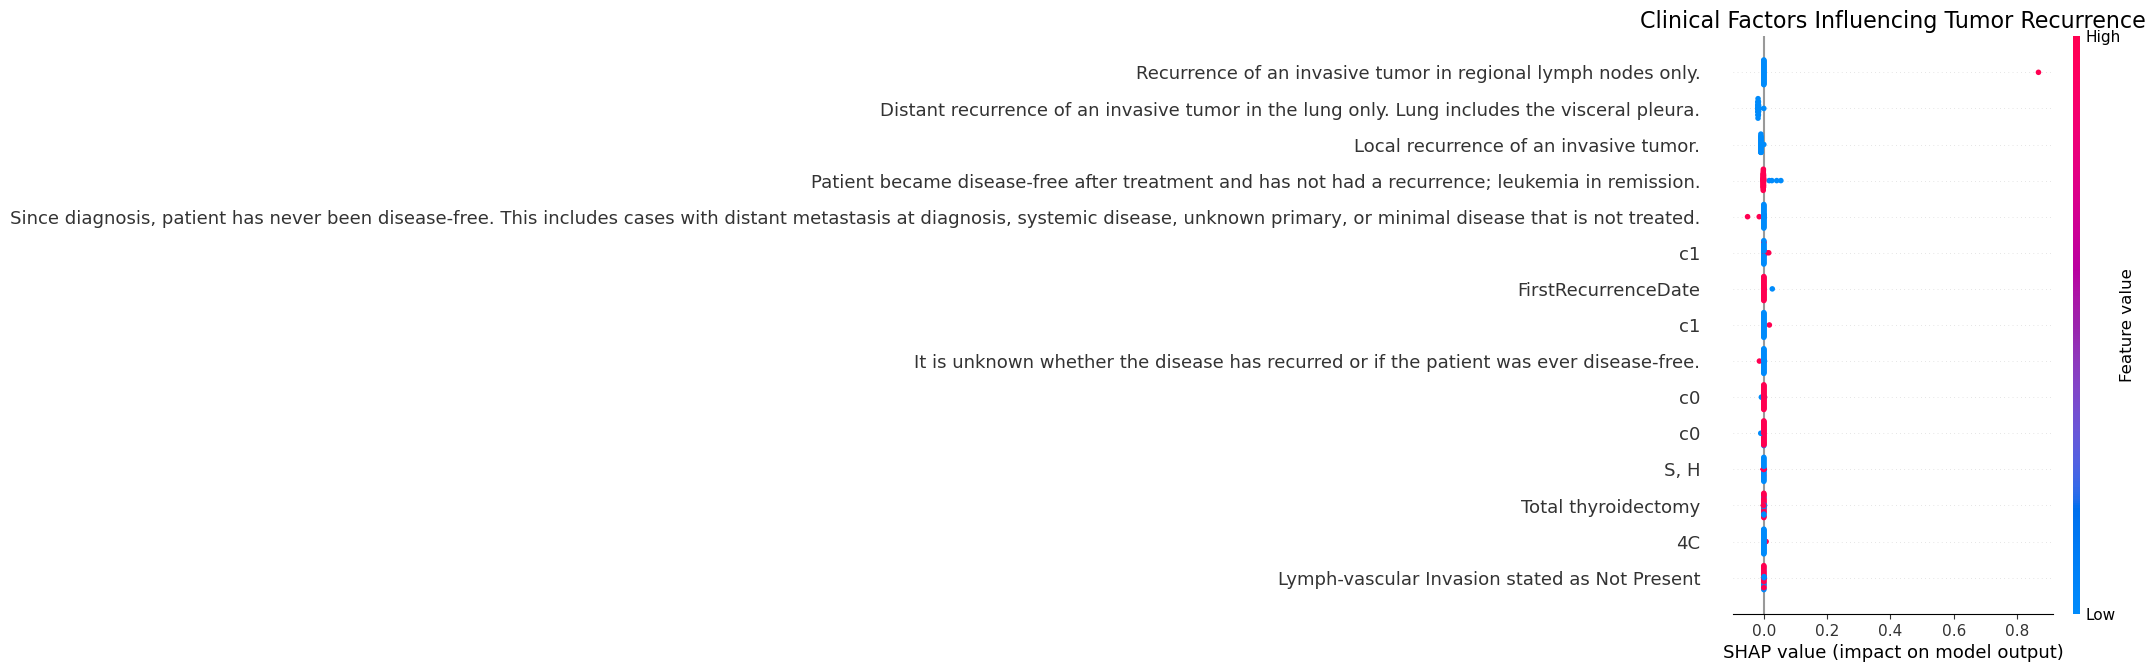

In [43]:
import shap
import matplotlib.pyplot as plt

# 1. CLEANING FUNCTION:
# This removes the prefix (like 'FirstRecurrenceType_') to make it readable.
clean_feature_names = [col.split('_')[-1] if '_' in col else col for col in X_train.columns]

# 2. RUN SHAP (Ensure you use the clean names)
# We set a wide figure size (16 inches) to handle the long medical descriptions
plt.figure(figsize=(16, 10))

shap.summary_plot(
    shap_values,
    test_samples,
    feature_names=clean_feature_names, # Use the cleaned list here
    max_display=15,                   # Showing fewer features makes it clearer
    show=False                        # Allow manual tweaks before showing
)

# 3. FIX MARGINS & FONT
# We use tight_layout to ensure the long labels on the left fit in the frame
plt.gcf().subplots_adjust(left=0.4) # Give 40% of the space to the labels
plt.title("Clinical Factors Influencing Tumor Recurrence", fontsize=16)
plt.show()

PermutationExplainer explainer: 51it [00:24,  2.08it/s]                                                                


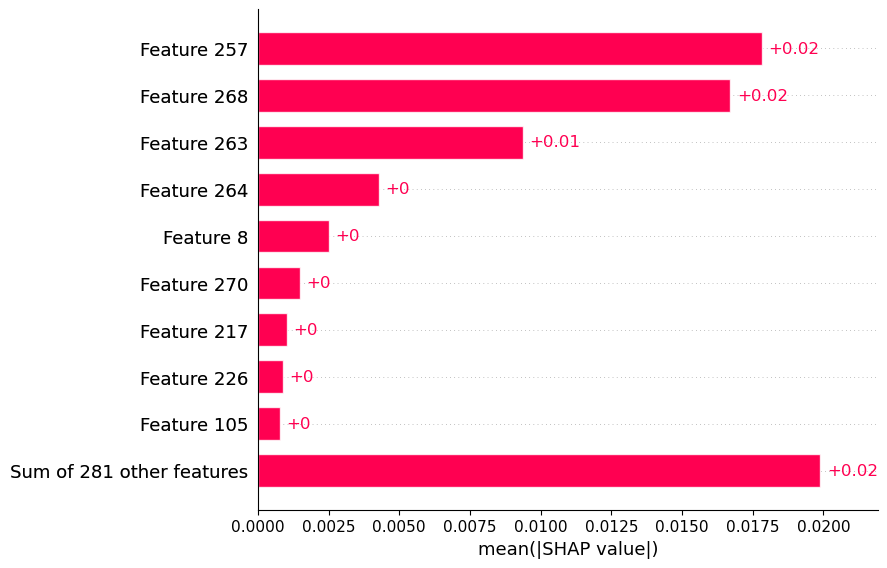

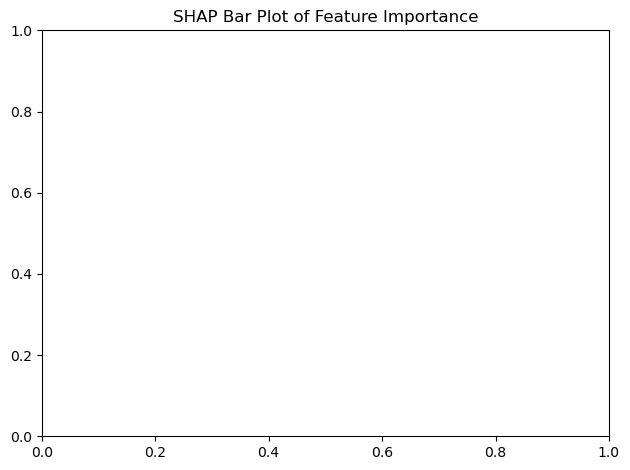

In [47]:
import shap
import matplotlib.pyplot as plt

# Ensure shap_values_obj is defined
# (These lines are typically found in the cell where waterfall plot was generated)
background = X_train_scaled[:100] # Assuming X_train_scaled is already defined
test_samples = X_test_scaled[:50] # Assuming X_test_scaled is already defined
explainer_obj = shap.Explainer(lambda x: best_mlp.predict_proba(x)[:, 1], background) # Assuming best_mlp is already defined
shap_values_obj = explainer_obj(test_samples)

# A Bar Plot simplifies the view to just 'Importance'
plt.figure(figsize=(12, 8))
shap.plots.bar(shap_values_obj, max_display=10)
plt.title('SHAP Bar Plot of Feature Importance')
plt.tight_layout()
plt.show()

## **Explaining a Single Prediction (Force Plot)**
How a single row was classified, use a Force Plot.

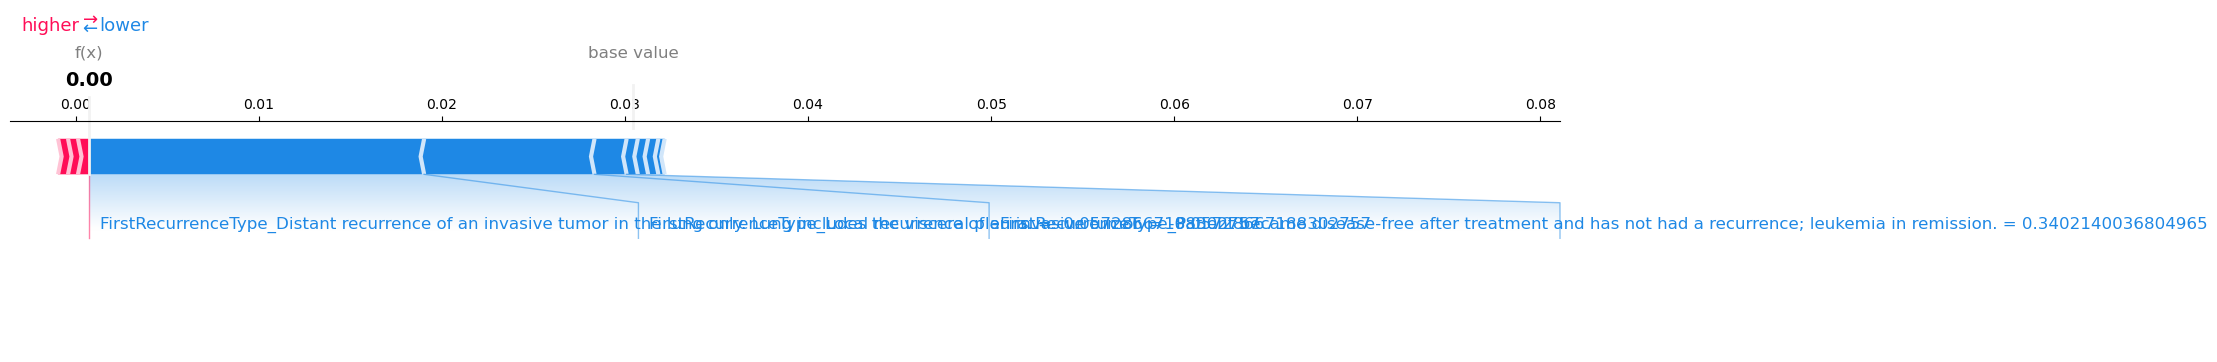

In [48]:
# Visualize the first prediction's explanation
shap.initjs() # Required for notebook visualization
shap.force_plot(
    explainer.expected_value,
    shap_values[0,:],
    test_samples[0,:],
    feature_names=X_train.columns,
    matplotlib=True
)

  0%|          | 0/100 [00:00<?, ?it/s]

<Figure size 1000x600 with 0 Axes>

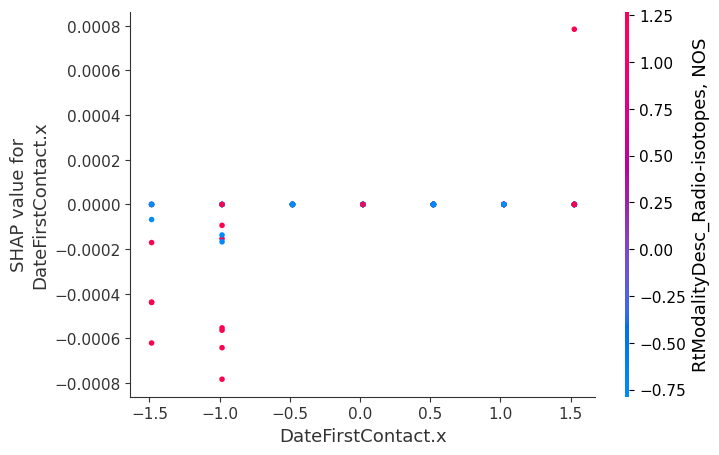

In [50]:
# Select the top feature from your previous summary plot (e.g., the first recurrence type)
# This reveals if higher values of a feature increase or decrease the risk

# Re-calculate shap_values and test_samples with more data points to avoid IndexError
# The original error indicates that 40 samples were not enough for dependence_plot
background = X_train_scaled[:100] # Use a consistent background as in other SHAP cells
explainer = shap.KernelExplainer(lambda x: best_mlp.predict_proba(x)[:, 1], background)
test_samples_for_plot = X_test_scaled[:100] # Increase sample size for robustness
shap_values_for_plot = explainer.shap_values(test_samples_for_plot)

top_feature = X_train.columns[0] # Using the first feature as an example

plt.figure(figsize=(10, 6))
shap.dependence_plot(top_feature, shap_values_for_plot, test_samples_for_plot, feature_names=X_train.columns)
plt.show()

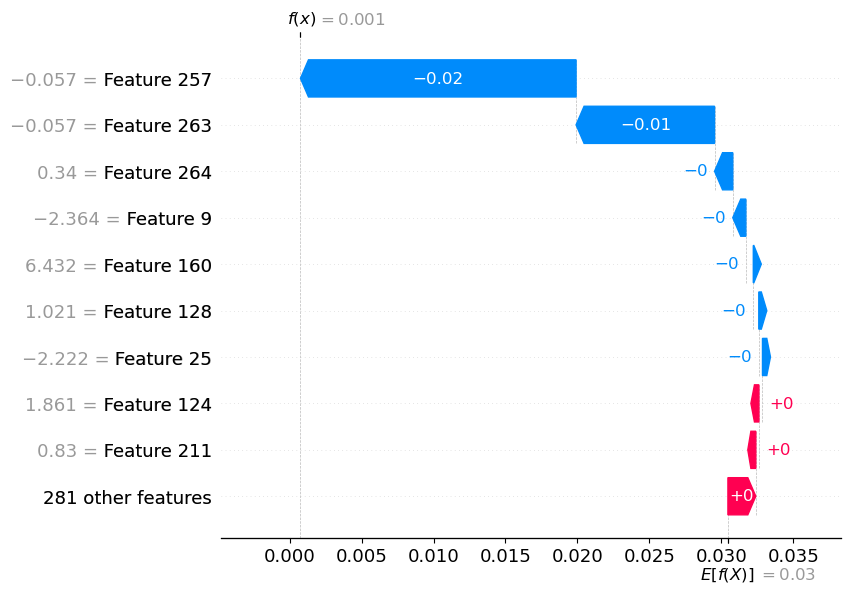

In [51]:
# To use the waterfall plot, we need an Explanation object
# We'll explain the very first person in our test_samples
explainer_obj = shap.Explainer(lambda x: best_mlp.predict_proba(x)[:, 1], background)
shap_values_obj = explainer_obj(test_samples)

plt.figure(figsize=(12, 8))
# Explain the 1st patient (index 0)
shap.plots.waterfall(shap_values_obj[0], max_display=10)

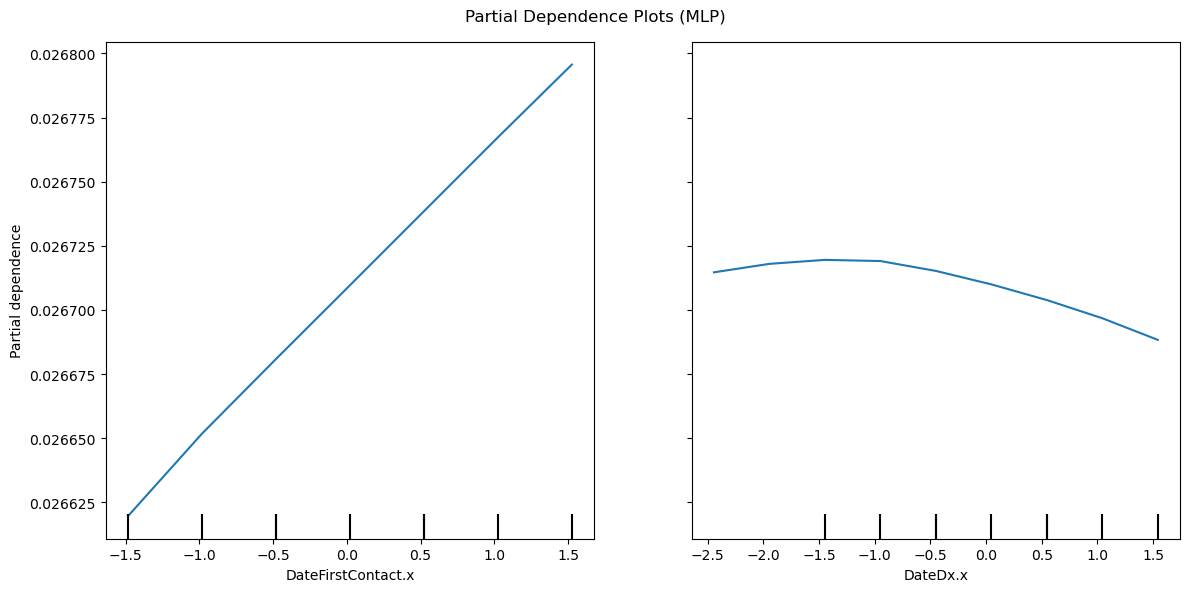

In [52]:
from sklearn.inspection import PartialDependenceDisplay

# Select top 2 features to compare
features_to_plot = [X_train.columns[0], X_train.columns[1]]

fig, ax = plt.subplots(figsize=(12, 6))
PartialDependenceDisplay.from_estimator(best_mlp, X_train_scaled, features_to_plot,
                                        feature_names=X_train.columns, ax=ax)
plt.suptitle("Partial Dependence Plots (MLP)")
plt.tight_layout()
plt.show()